In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
dates = pd.date_range(start='2026-06-15', end='2026-07-15').strftime('%Y-%m-%d').tolist()
dates.remove('2026-06-20')
dates.remove('2026-07-02')

data = {
    'Log_Date': dates,
    'Weight_lbs': [134.2, 134.5, 134.4, '134.8 lbs', 135.0, 135.2, 135.1, None, 135.6, 135.8, 
                  135.5, 136.0, 136.2, 136.1, 136.5, 136.8, None, 137.2, 137.0, 137.5, 
                  137.8, 137.6, 138.0, 138.4, '138.2 lbs', 138.8, 139.0, 138.9, 139.3],
    'Calories': [2800, 2950, 'missing', 3100, 3000, 3200, 2900, 3150, 3300, 3000,
                 'none', 3250, 3400, 3100, 3200, 3450, 3300, 3100, 3500, 3250,
                 3300, 3400, 3150, 3550, 3600, 3400, 3300, 3650, 3700],
    'Protein_g': [140, 145, 120, 150, 148, 155, 135, 150, 160, 145,
                  110, 152, 165, 140, 150, 168, 155, 142, 170, 158,
                  160, 165, 145, 172, 175, 168, 155, 178, 180],
    'Workout_Type': ['Gym', 'gym', 'Rest', 'GYM', 'Rest day', 'Gym', 'rest', 'Gym', 'Gym', 'Rest',
                    'rest day', 'Gym', 'GYM', 'Rest', 'Gym', 'Gym', 'Rest', 'Gym', 'Gym', 'Rest',
                    'Gym', 'GYM', 'Rest', 'Gym', 'Gym', 'Rest', 'Gym', 'Gym', 'Gym']
}
df_fitness = pd.DataFrame(data)

In [3]:
df_fitness

,Log_Date,Weight_lbs,Calories,Protein_g,Workout_Type
0,2026-06-15,134.2,2800,140,Gym
1,2026-06-16,134.5,2950,145,gym
2,2026-06-17,134.4,missing,120,Rest
3,2026-06-18,134.8 lbs,3100,150,GYM
4,2026-06-19,135.0,3000,148,Rest day
5,2026-06-21,135.2,3200,155,Gym
6,2026-06-22,135.1,2900,135,rest
7,2026-06-23,None,3150,150,Gym
8,2026-06-24,135.6,3300,160,Gym
9,2026-06-25,135.8,3000,145,Rest


In [4]:
df_fitness['Log_Date'] = pd.to_datetime(df_fitness['Log_Date'])
df_fitness.set_index('Log_Date', inplace=True)
df_fitness = df_fitness.asfreq('D')

In [5]:
df_fitness.head()

,Weight_lbs,Calories,Protein_g,Workout_Type
Log_Date,,,,
2026-06-15,134.2,2800,140.0,Gym
2026-06-16,134.5,2950,145.0,gym
2026-06-17,134.4,missing,120.0,Rest
2026-06-18,134.8 lbs,3100,150.0,GYM
2026-06-19,135.0,3000,148.0,Rest day


In [6]:
df_fitness['Weight_lbs'] = df_fitness['Weight_lbs'].astype(str).str.replace(' lbs', '', regex=False)
df_fitness['Weight_lbs'] = pd.to_numeric(df_fitness['Weight_lbs'], errors='coerce')
df_fitness['Weight_lbs'] = df_fitness['Weight_lbs'].ffill()
df_fitness['Weight_kg'] = df_fitness['Weight_lbs'] * 0.453592

In [7]:
df_fitness.head()

,Weight_lbs,Calories,Protein_g,Workout_Type,Weight_kg
Log_Date,,,,,
2026-06-15,134.2,2800,140.0,Gym,60.872046
2026-06-16,134.5,2950,145.0,gym,61.008124
2026-06-17,134.4,missing,120.0,Rest,60.962765
2026-06-18,134.8,3100,150.0,GYM,61.144202
2026-06-19,135.0,3000,148.0,Rest day,61.234920


In [8]:
df_fitness['Calories'] = pd.to_numeric(df_fitness['Calories'].replace(['missing', 'none'], '3200'), errors='coerce')
df_fitness['Calories'] = df_fitness['Calories'].fillna(3200).astype(int)

In [11]:
df_fitness['Protein_g'] = df_fitness['Protein_g'].astype(int)

In [12]:
df_fitness['Workout_Type'] = df_fitness['Workout_Type'].str.lower().str.replace('rest day', 'rest')


In [13]:
df_fitness

,Weight_lbs,Calories,Protein_g,Workout_Type,Weight_kg
Log_Date,,,,,
2026-06-15,134.2,2800,140,gym,60.872046
2026-06-16,134.5,2950,145,gym,61.008124
2026-06-17,134.4,3200,120,rest,60.962765
2026-06-18,134.8,3100,150,gym,61.144202
2026-06-19,135.0,3000,148,rest,61.234920
2026-06-20,135.0,3200,150,rest,61.234920
2026-06-21,135.2,3200,155,gym,61.325638
2026-06-22,135.1,2900,135,rest,61.280279
2026-06-23,135.1,3150,150,gym,61.280279


In [14]:
df_fitness['Weight_Rolling_kg'] = df_fitness['Weight_kg'].rolling(7).mean()

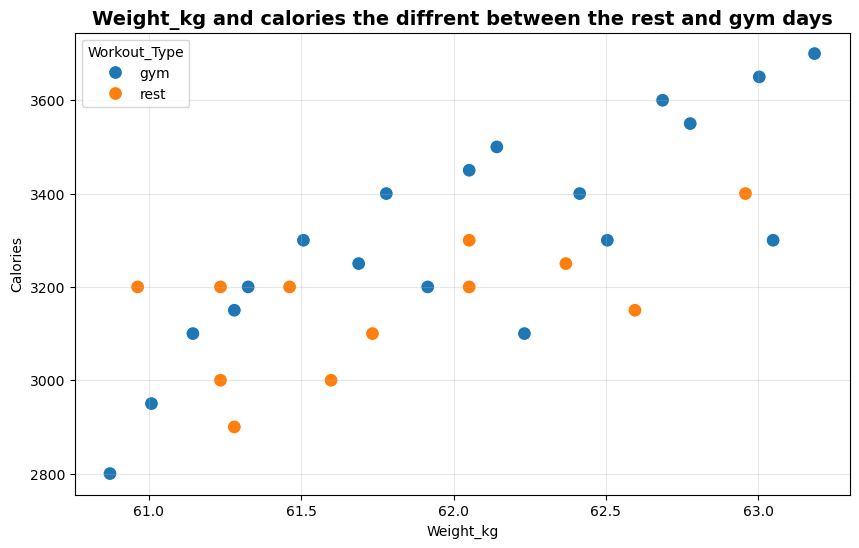

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fitness, x='Weight_kg', y='Calories', hue='Workout_Type', s=100)
plt.title('Weight_kg and calories the diffrent between the rest and gym days', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()